In [90]:
import numpy as np
from scipy.spatial.distance import cdist

In [91]:
# --- 1. Correlation-based attention ---
def correlation_attention(df1_window, df2_windows):
    scores = []
    for i in range(df2_windows.shape[0]):
        df2_window = df2_windows[i]
        # Make sure df2_window is 2D
        if df2_window.ndim == 1:
            df2_window = df2_window.reshape(-1, df1_window.shape[1])
        # Compute mean correlation
        col_corrs = [np.corrcoef(df1_window[:, j], df2_window[:, j])[0, 1] 
                     for j in range(df1_window.shape[1])]
        scores.append(np.nanmean(col_corrs))
    scores = np.array(scores)
    most_attended_idx = np.argmax(scores)
    return most_attended_idx, scores



# --- 2. Cosine similarity attention ---
def cosine_attention(df1_window, df2_windows):
    """
    Returns cosine similarity scores between df1_window and all windows in df2.
    Each window is flattened.
    """
    w1 = df1_window.flatten()
    scores = []
    for i in range(df2_windows.shape[0]):
        w2 = df2_windows[i].flatten()
        cos_sim = np.dot(w1, w2) / (np.linalg.norm(w1) * np.linalg.norm(w2))
        scores.append(cos_sim)
    scores = np.array(scores)
    most_attended_idx = np.argmax(scores)
    return most_attended_idx, scores


# --- 3. Softmax-weighted attention ---
def softmax_attention(df1_window, df2_windows, similarity_func='cosine'):
    """
    Computes softmax-weighted attention scores using a similarity function
    ('cosine' or 'correlation').
    """
    if similarity_func == 'cosine':
        _, raw_scores = cosine_attention(df1_window, df2_windows)
    elif similarity_func == 'correlation':
        _, raw_scores = correlation_attention(df1_window, df2_windows)
    else:
        raise ValueError("similarity_func must be 'cosine' or 'correlation'")
    
    # Softmax normalization
    exp_scores = np.exp(raw_scores - np.max(raw_scores))  # numerical stability
    attention_weights = exp_scores / np.sum(exp_scores)
    
    most_attended_idx = np.argmax(attention_weights)
    return most_attended_idx, attention_weights


# --- 4. Distance-based attention (inverse distance) ---
def distance_attention(df1_window, df2_windows, metric='euclidean'):
    """
    Computes attention based on inverse distance (closer = more attended).
    metric can be 'euclidean', 'cityblock', 'mahalanobis', etc.
    """
    w1 = df1_window.flatten().reshape(1, -1)
    all_w2 = np.array([w.flatten() for w in df2_windows])
    
    distances = cdist(w1, all_w2, metric=metric).flatten()
    # Convert to attention scores (higher = more attended)
    scores = 1 / (1 + distances)
    most_attended_idx = np.argmax(scores)
    return most_attended_idx, scores


from scipy.stats import pearsonr

def window_correlation_scipy(window1, window2):
    """
    Compute the mean Pearson correlation across columns using scipy.
    """
    col_corrs = []
    for i in range(window1.shape[1]):
        r, _ = pearsonr(window1[:, i], window2[:, i])
        col_corrs.append(r)
    return np.nanmean(col_corrs)

import pandas as pd

def window_correlation_pandas(window1, window2):
    """
    Compute the mean correlation using pandas DataFrame corr method.
    """
    df1 = pd.DataFrame(window1)
    df2 = pd.DataFrame(window2)
    col_corrs = [df1[i].corr(df2[i]) for i in range(df1.shape[1])]
    return np.nanmean(col_corrs)

In [92]:
importance_func = window_correlation_pandas

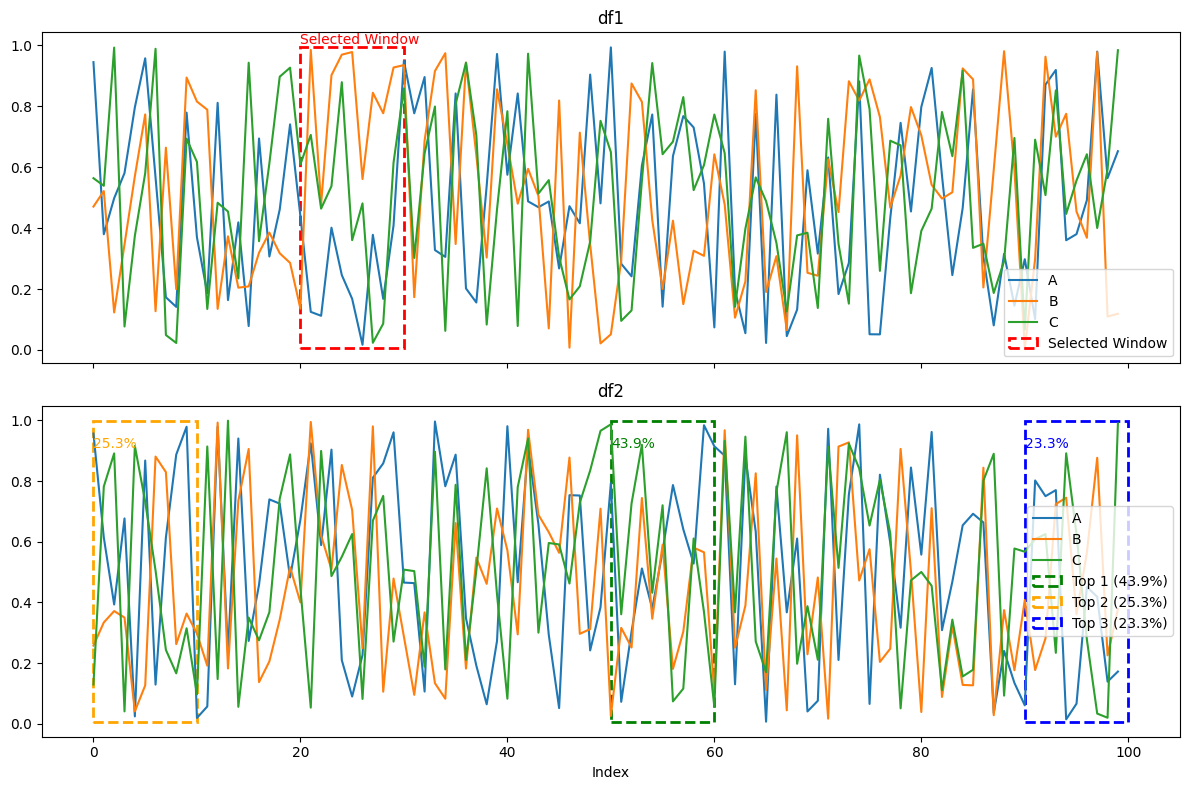

Top correlations:
Rank 1: df2 window 5 -> 43.94%
Rank 2: df2 window 0 -> 25.30%
Rank 3: df2 window 9 -> 23.27%


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Step 1: Create example DataFrames ---
df1 = pd.DataFrame(np.random.rand(100, 3), columns=['A', 'B', 'C'])
df2 = pd.DataFrame(np.random.rand(100, 3), columns=['A', 'B', 'C'])

# --- Step 2: Split DataFrames into windows ---
def split_df(df, n_parts=10):
    window_size = len(df) // n_parts
    windows = [(i*window_size, (i+1)*window_size) for i in range(n_parts)]
    return windows

windows_df1 = split_df(df1)
windows_df2 = split_df(df2)


# --- Step 3: Compare a df1 window with all df2 windows ---
def compare_window(df1_window_index):
    start1, end1 = windows_df1[df1_window_index]
    selected_window = df1.iloc[start1:end1].values
    correlations = []

    for start2, end2 in windows_df2:
        df2_window = df2.iloc[start2:end2].values
        correlations.append(importance_func(selected_window, df2_window))

    return correlations

# --- Step 4: Plot df1 and df2 with top N correlations ---
def plot_top_correlations(window_index, top_n=3):
    correlations = compare_window(window_index)
    best_indices = np.argsort(correlations)[-top_n:][::-1]  # top N windows
    best_corrs = [correlations[i]*100 for i in best_indices]
    
    start1, end1 = windows_df1[window_index]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # df1 plot
    axes[0].plot(df1.index, df1['A'], label='A')
    axes[0].plot(df1.index, df1['B'], label='B')
    axes[0].plot(df1.index, df1['C'], label='C')
    rect1 = patches.Rectangle(
        (start1, df1.min().min()), end1-start1, df1.max().max()-df1.min().min(),
        linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Selected Window'
    )
    axes[0].add_patch(rect1)
    axes[0].text(start1, df1.max().max(), f"Selected Window", color='red', fontsize=10, verticalalignment='bottom')
    axes[0].set_title('df1')
    axes[0].legend()

    # df2 plot
    axes[1].plot(df2.index, df2['A'], label='A')
    axes[1].plot(df2.index, df2['B'], label='B')
    axes[1].plot(df2.index, df2['C'], label='C')

    colors = ['green', 'orange', 'blue']  # colors for top correlations
    for rank, idx in enumerate(best_indices):
        start2, end2 = windows_df2[idx]
        rect = patches.Rectangle(
            (start2, df2.min().min()), end2-start2, df2.max().max()-df2.min().min(),
            linewidth=2, edgecolor=colors[rank], facecolor='none', linestyle='--',
            label=f'Top {rank+1} ({best_corrs[rank]:.1f}%)'
        )
        axes[1].add_patch(rect)
        axes[1].text(start2, df2.max().max()*0.9, f"{best_corrs[rank]:.1f}%", color=colors[rank],
                     fontsize=10, verticalalignment='bottom')

    axes[1].set_title('df2')
    axes[1].legend()
    plt.xlabel('Index')
    plt.tight_layout()
    plt.show()

    print("Top correlations:")
    for rank, idx in enumerate(best_indices):
        print(f"Rank {rank+1}: df2 window {idx} -> {best_corrs[rank]:.2f}%")

# --- Step 5: Select window to visualize ---
selected_window_index = 2
plot_top_correlations(selected_window_index)


In [122]:
import shap
import numpy as np

def compute_shap_window_importance(model, X, n_feature_windows, window_size, background_sample_size=100):
    """
    Compute SHAP-based importance for contiguous feature windows.

    Parameters
    ----------
    model : trained model
        Any fitted model with a .predict method.
    X : ndarray of shape (n_samples, n_features)
        Input data.
    n_feature_windows : int
        Number of windows to split features into.
    window_size : int
        Number of features per window.
    background_sample_size : int, optional
        Sample size for KernelExplainer background. Default is 100.

    Returns
    -------
    SHAP_window_importance : list of float
        SHAP importance score per feature window.
    """
    # -------------------------------
    # Step 1: choose SHAP explainer
    # -------------------------------
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
    except Exception:
        # fallback for general models
        idx = np.random.choice(X.shape[0], min(background_sample_size, X.shape[0]), replace=False)
        X_background = X[idx]
        explainer = shap.KernelExplainer(model.predict, X_background)
        shap_values = explainer.shap_values(X)

    # -------------------------------
    # Step 2: compute mean absolute SHAP per feature
    # -------------------------------
    if isinstance(shap_values, list):
        shap_values = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        shap_values = np.abs(shap_values)

    shap_per_feature = np.mean(shap_values, axis=0)

    # -------------------------------
    # Step 3: sum SHAP values per window
    # -------------------------------
    SHAP_window_importance = []
    for w in range(n_feature_windows):
        start = w * window_size
        end = min((w+1) * window_size, X.shape[1])
        window_importance = np.sum(shap_per_feature[start:end])
        SHAP_window_importance.append(window_importance)

    return SHAP_window_importance


In [119]:
method_num = 4    #1,3,5,6,(7),8,9,10,11

[np.float64(0.5611783381420132), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


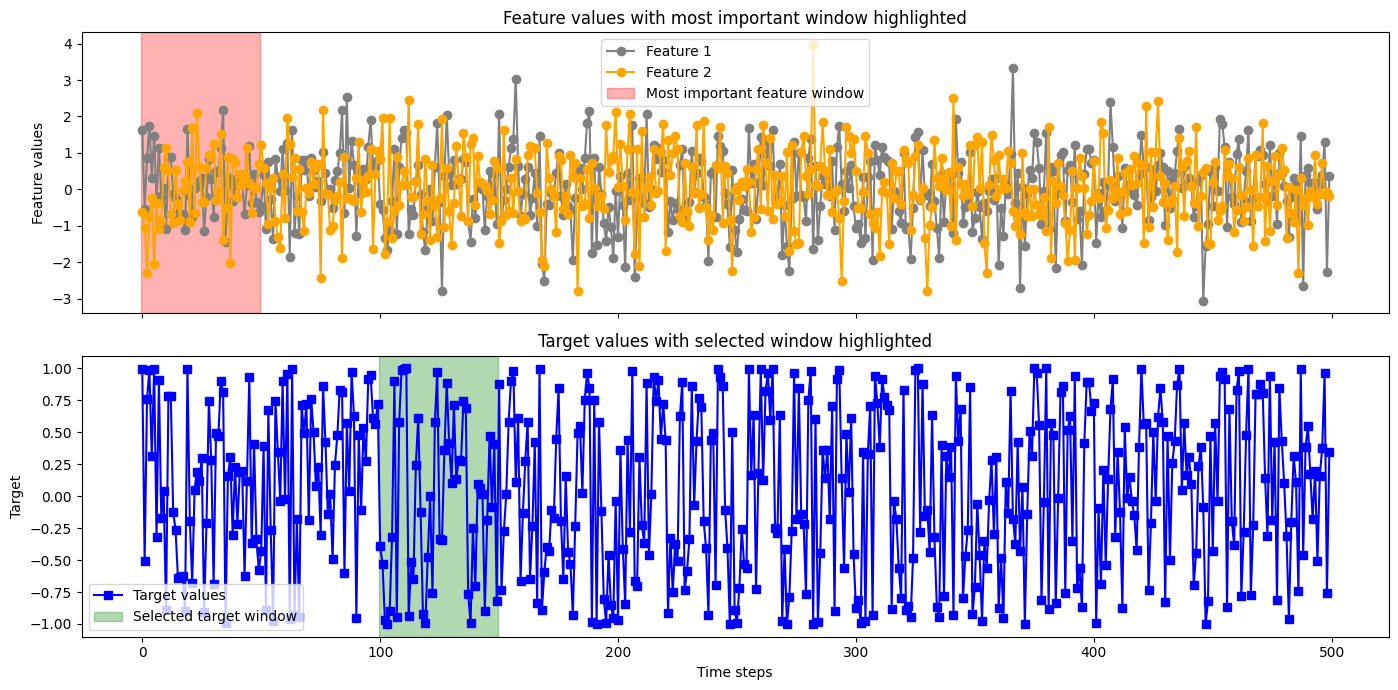

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------------------
# 1. Generate synthetic data
# ---------------------------
np.random.seed(1)
n_timesteps = 500
n_features = 2  # multiple feature columns

X = np.random.randn(n_timesteps, n_features)
y = np.sin(X[:, 0])

# ---------------------------
# 2. Define windows
# ---------------------------
window_size = 50
n_feature_windows = n_timesteps // window_size
n_target_windows = n_timesteps // window_size

target_window_idx = 2
target_start = target_window_idx * window_size
target_end = target_start + window_size
target_window = y[target_start:target_end]

# ---------------------------
# 3. Fit model
# ---------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# ---------------------------
# 4. Compute feature window importance
# ---------------------------
feature_window_importance = []
match method_num:
    case 1:
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size

            X_perm = X.copy()
            for f in range(n_features):
                X_perm[start:end, f] = np.random.permutation(X_perm[start:end, f])

            y_hat = model.predict(X_perm)
            imp = np.mean(np.abs(y - y_hat))  # use entire target vector
            feature_window_importance.append(imp)
    case 2:
        mdi_importance = model.feature_importances_
        for w in range(n_feature_windows):
            # sum importance of all features (here we just repeat same sum for simplicity)
            feature_window_importance.append(np.sum(mdi_importance))     
    case 3:        
        feature_window_importance = []
        for w in range(n_feature_windows):
            X_masked = X.copy()
            X_masked[w*window_size:(w+1)*window_size, :] = 0  # mask the window
            y_hat = model.predict(X_masked)
            err = np.mean(np.abs(y - y_hat))
            feature_window_importance.append(err)
    
    case 4:        
        feature_window_importance = compute_shap_window_importance(
                                                        model=model,
                                                        X=X,
                                                        n_feature_windows=n_feature_windows,
                                                        window_size=window_size
                                                        )

    case 5:
        feature_window_importance = []
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size
            corr = np.corrcoef(X[start:end, 0], y[start:end])[0, 1]
            feature_window_importance.append(corr)
    
    case 6:  # Sliding occlusion (mask a smaller slice inside window)
        feature_window_importance = []
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size
            # mask only half of the window for smoother importance
            mid = (start + end) // 2
            X_mod = X.copy()
            X_mod[mid:end, :] = 0
            y_hat = model.predict(X_mod)
            err = np.mean(np.abs(y - y_hat))
            feature_window_importance.append(err)

    case 7:  # Noise infusion
        feature_window_importance = []
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size
            X_mod = X.copy()
            noise = np.random.normal(0, 0.5, size=(end-start, n_features))
            X_mod[start:end] += noise
            y_hat = model.predict(X_mod)
            err = np.mean(np.abs(y - y_hat))
            feature_window_importance.append(err)

    case 8:  # Counterfactual imputation (replace with window mean)
        feature_window_importance = []
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size
            X_mod = X.copy()
            X_mod[start:end, :] = np.mean(X, axis=0)
            y_hat = model.predict(X_mod)
            err = np.mean(np.abs(y - y_hat))
            feature_window_importance.append(err)

    case 9:  # Mutual Information (statistical, model-free)
        from sklearn.feature_selection import mutual_info_regression
        feature_window_importance = []
        for w in range(n_feature_windows):
            start = w * window_size
            end = start + window_size
            mi = mutual_info_regression(X[start:end], y[start:end], random_state=42)
            feature_window_importance.append(np.mean(mi))

    case 10:  # Leave-one-window-out retrain (expensive)
        feature_window_importance = []
        from sklearn.model_selection import train_test_split
        from sklearn.metrics import mean_absolute_error
        # baseline error
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
        base_model = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_train, y_train)
        base_err = mean_absolute_error(y_test, base_model.predict(X_test))
        # retrain without each window
        for w in range(n_feature_windows):
            mask = np.ones(len(X_train), dtype=bool)
            mask[(w*window_size < np.arange(len(X_train))) & (np.arange(len(X_train)) < (w+1)*window_size)] = False
            X_train_reduced, y_train_reduced = X_train[mask], y_train[mask]
            model_reduced = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_train_reduced, y_train_reduced)
            err = mean_absolute_error(y_test, model_reduced.predict(X_test))
            feature_window_importance.append(err - base_err)
    case 11:  # Attention model surrogate
        

        # Build tiny Transformer
        class TinyTransformer(nn.Module):
            def __init__(self, d_model=16, nhead=2, num_layers=1):
                super().__init__()
                self.input_proj = nn.Linear(n_features, d_model)
                enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
                self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
                self.fc = nn.Linear(d_model, 1)
            def forward(self, x):
                x = self.input_proj(x)
                att_out = self.encoder(x)  # shape (batch, seq, d_model)
                out = self.fc(att_out).squeeze(-1).mean(dim=1)
                return out, att_out

        # Prepare data as sequence
        X_torch = torch.tensor(X, dtype=torch.float32).unsqueeze(0)  # batch=1
        y_torch = torch.tensor(y, dtype=torch.float32).unsqueeze(0)

        model_att = TinyTransformer()
        optimizer = optim.Adam(model_att.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        # Quick training
        for epoch in range(50):
            optimizer.zero_grad()
            out, _ = model_att(X_torch)
            loss = loss_fn(out, y_torch)
            loss.backward()
            optimizer.step()

        # Extract attention indirectly via encoder outputs (proxy: variance in hidden states)
        _, att_out = model_att(X_torch)
        att_energy = att_out.var(dim=-1).detach().numpy()[0]  # (seq_len,)
        feature_window_importance = [
            np.mean(att_energy[w*window_size:(w+1)*window_size]) for w in range(n_feature_windows)
        ]
    
    case 12:  # Change-point-aware windows
        import ruptures as rpt

        # Detect change points on target signal
        algo = rpt.KernelCPD(kernel="linear").fit(y)
        cps = algo.predict(n_bkps=5)  # choose ~5 breakpoints
        segments = [0] + cps

        feature_window_importance = []
        for i in range(len(segments)-1):
            start, end = segments[i], segments[i+1]
            X_masked = X.copy()
            X_masked[start:end, :] = 0
            y_hat = model.predict(X_masked)
            err = np.mean(np.abs(y - y_hat))
            feature_window_importance.append(err)
    case 13:  # LSTM-based feature window importance (occlusion) with PyTorch
        import torch
        import torch.nn as nn
        import torch.optim as optim
        from torch.utils.data import DataLoader, TensorDataset

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        class LSTMModel(nn.Module):
            def __init__(self, input_dim, hidden_dim=32, num_layers=1):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
                self.fc = nn.Linear(hidden_dim, 1)

            def forward(self, x):
                out, _ = self.lstm(x)
                out = self.fc(out[:, -1, :])  # Use last timestep output
                return out.squeeze(-1)

        # Prepare sequences for LSTM (samples, seq_len, features)
        seq_len = window_size
        X_seqs = []
        y_seqs = []
        for i in range(n_timesteps - seq_len):
            X_seqs.append(X[i:i+seq_len])
            y_seqs.append(y[i+seq_len-1])
        X_seqs = np.array(X_seqs)
        y_seqs = np.array(y_seqs)

        # Convert to tensors
        X_tensor = torch.tensor(X_seqs, dtype=torch.float32).to(device)
        y_tensor = torch.tensor(y_seqs, dtype=torch.float32).to(device)

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

        model_lstm = LSTMModel(input_dim=n_features).to(device)
        optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        # Train LSTM quickly
        model_lstm.train()
        for epoch in range(10):
            for xb, yb in dataloader:
                optimizer.zero_grad()
                preds = model_lstm(xb)
                loss = loss_fn(preds, yb)
                loss.backward()
                optimizer.step()

        model_lstm.eval()
        with torch.no_grad():
            base_preds = model_lstm(X_tensor).cpu().numpy()
        baseline_err = np.mean(np.abs(y_seqs - base_preds))

        # Occlusion-based window importance
        feature_window_importance = []
        n_windows = (X_seqs.shape[1] + window_size - 1) // window_size  # number of windows per sequence

        for w in range(n_windows):
            X_masked = X_tensor.clone()
            start = w * window_size
            end = min(start + window_size, X_tensor.shape[1])
            # Mask window in all sequences (set features to zero)
            X_masked[:, start:end, :] = 0
            with torch.no_grad():
                preds_masked = model_lstm(X_masked).cpu().numpy()
            err = np.mean(np.abs(y_seqs - preds_masked))
            feature_window_importance.append(err - baseline_err)


print(feature_window_importance)
# Find the most important feature window
most_important_window = np.argmax(feature_window_importance)
feature_start = most_important_window * window_size
feature_end = feature_start + window_size
# ---------------------------
# 5. Plot
# ---------------------------
timesteps = np.arange(n_timesteps)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: feature values
colors = ['gray', 'orange', 'purple', 'green', 'brown']
for f in range(n_features):
    axes[0].plot(timesteps, X[:, f], marker='o', color=colors[f], label=f'Feature {f+1}')
axes[0].axvspan(feature_start-0.5, feature_end-0.5, color='red', alpha=0.3, label='Most important feature window')
axes[0].set_ylabel("Feature values")
axes[0].set_title("Feature values with most important window highlighted")
axes[0].legend()

# Bottom: target values
axes[1].plot(timesteps, y, marker='s', color='blue', label='Target values')
axes[1].axvspan(target_start-0.5, target_end-0.5, color='green', alpha=0.3, label='Selected target window')
axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Target")
axes[1].set_title("Target values with selected window highlighted")
axes[1].legend()

plt.tight_layout()
plt.show()


In [113]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
diabetes = load_diabetes()
X_train, X_val, y_train, y_val = train_test_split(
    diabetes.data, diabetes.target, random_state=0)
model = Ridge(alpha=1e-2).fit(X_train, y_train)
model.score(X_val, y_val)

0.356667532293942

In [114]:
from sklearn.inspection import permutation_importance
r = permutation_importance(model, X_val, y_val,
                           n_repeats=30,
                           random_state=0)
for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{diabetes.feature_names[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

s5      0.204 +/- 0.050
bmi     0.176 +/- 0.048
bp      0.088 +/- 0.033
sex     0.056 +/- 0.023


In [135]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

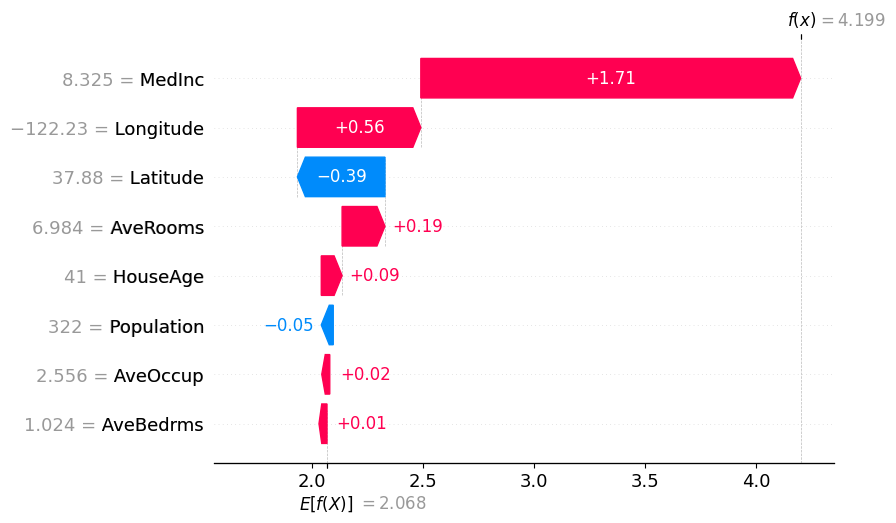

In [129]:
import xgboost
import shap

# train an XGBoost model
X, y = shap.datasets.california()
model = xgboost.XGBRegressor().fit(X, y)

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(model)
shap_values = explainer(X)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

In [128]:
# visualize all the training set predictions
shap.plots.force(shap_values[:500])